In [1]:
import os
import sys
sys.path.append('..')
import torch
import glob
import pandas as pd
import librosa
import tqdm
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from libs.model import w2v2XLSRModel
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader
from libs.dataloader import AccentDataset, accent_collate_fn, id2label, label2id

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/mtseng/miniconda3/envs/DarkStream/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mtseng/miniconda3/envs/DarkStream/lib/python3.10/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
/data/mtseng/voice_datasets/CommonVoice_v11/libs/model.py:10: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'sp

In [2]:
model = w2v2XLSRModel()
model = model.to(device)

/home/mtseng/miniconda3/envs/DarkStream/lib/python3.10/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
speechbrain.lobes.models.huggingface_transformers.huggingface - Wav2Vec2Model is frozen.
/home/mtseng/miniconda3/envs/DarkStream/lib/python3.10/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()


In [9]:
test_df = pd.read_csv("./metadata/test.csv")
print(test_df.head())

                                          audio_path  duration  \
0  /data/mtseng/voice_datasets/CommonVoice_v11/da...     1.296   
1  /data/mtseng/voice_datasets/CommonVoice_v11/da...     3.144   
2  /data/mtseng/voice_datasets/CommonVoice_v11/da...     4.416   
3  /data/mtseng/voice_datasets/CommonVoice_v11/da...     2.016   
4  /data/mtseng/voice_datasets/CommonVoice_v11/da...     2.976   

                                                text subject_id  \
0                     EVERYTHING'LL BE TAKEN CARE OF  sample-00   
1                  I HAVE TO SEPARATE OUT THE SULFUR  sample-00   
2  KELLY WAS INTERESTED IN CLEARING UP HER BROTHE...  sample-00   
3                                PUT DOWN THAT CHAIR  sample-00   
4       I HAD TO TEST YOUR COURAGE THE STRANGER SAID  sample-00   

          utt_id    accent  
0  sample-001005  american  
1  sample-001030  american  
2  sample-001052  american  
3  sample-001054  american  
4  sample-001064  american  


In [10]:
model.eval()
features_dict = defaultdict(list)
with torch.no_grad():
    for _, row in tqdm.tqdm(test_df.iterrows(), total=len(test_df)):
        wav_path = os.path.join("/data/mtseng/voice_datasets", row["audio_path"])
        wav, sr = librosa.load(wav_path, sr=16000)
        wav_tensor = torch.from_numpy(wav).float().unsqueeze(0).to(device)
        label = row["accent"]

        logits, out_prob, feats = model(wav_tensor)
        features_dict[label].append(feats[0].cpu().numpy())

for accent, feat_list in features_dict.items():
    features_dict[accent] = np.stack(feat_list)

100%|██████████| 1086/1086 [00:14<00:00, 74.71it/s]


In [11]:
# -------------------------
# Prepare feature matrix
# -------------------------
all_features = []
all_labels = []

for accent, feats in features_dict.items():
    all_features.append(feats)
    all_labels.extend([accent] * len(feats))

X = np.vstack(all_features)   # shape: (num_samples, 1024)
labels = np.array(all_labels)

print("Feature matrix:", X.shape)
print("Labels:", labels.shape)

Feature matrix: (1086, 1024)
Labels: (1086,)


In [15]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
)

X_2d = tsne.fit_transform(X)
accent_order = sorted(features_dict.keys())

# Use tab20 for many classes
cmap = plt.colormaps["tab20"]
base_colors = [cmap(i) for i in np.linspace(0, 1, len(accent_order))]

color_map = {
    accent: base_colors[i]
    for i, accent in enumerate(accent_order)
}

# Optional: manually make Spanish stand out
color_map["spanish"] = "black"

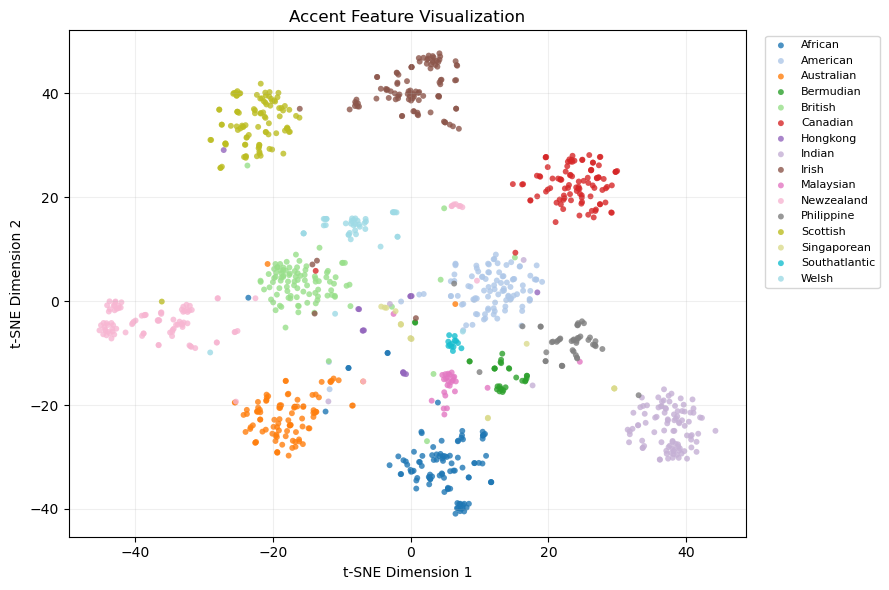

In [16]:
plt.figure(figsize=(9, 6))

for accent in accent_order:
    mask = labels == accent

    if accent == "spanish":
        plt.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            s=45,
            alpha=0.95,
            label="Spanish",
            color="black",
            marker="*",
            edgecolors="white",
            linewidths=0.6,
            zorder=5,
        )
    else:
        plt.scatter(
            X_2d[mask, 0],
            X_2d[mask, 1],
            s=18,
            alpha=0.8,
            label=accent.replace("_", " ").title(),
            color=color_map[accent],
            edgecolors="none",
        )

plt.title("Accent Feature Visualization")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(alpha=0.2)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    frameon=True,
)

plt.tight_layout()
plt.show()